# Longitudinal Cognitive Scores Comparison

Compare `factor_scores_theory` between assessments for longitudinal participants, separately for Cohort A and B

In [1]:
import os
import sys
# Ensure src is in path (notebook may run from project root or analyses/kw09)
_root = os.path.dirname(os.path.dirname(os.getcwd())) if 'analyses' in os.getcwd() else os.getcwd()
sys.path.insert(0, os.path.join(_root, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.config import Config
from config.constants import Constants
from config.run_parameters import RunParameters
from data_analysis.dataloader.dataloader import LuhaCombinedDataLoader
from data_analysis.dataloader.dataset import DatasetType
from scipy import stats

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")


/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataloader = LuhaCombinedDataLoader()
data = dataloader.load_data()

constants = Constants()

No task specified, loading pictureDescription
No consent_filter specified (consent for further data use), loading all participants
No task specified, loading pictureDescription
No consent_filter specified (consent for further data use), loading all participants
Initializing dataloader Luha 2024 Dataloader (transcript_version google, task pictureDescription) Split full
No task specified, loading pictureDescription
No consent_filter specified (consent for further data use), loading all participants
Initializing dataloader Luha 2026 Dataloader (transcript_version google, task pictureDescription)
Initializing Luha Combined Dataloader (task=pictureDescription, transcript_version=google, split=full, split_2024=full, only_longitudinal_participants=False), waves=None, use_averaged_factor_scores_theory=False
Loading data using Luha Combined Dataloader
Loading data using dataloader Luha 2024 Dataloader
Combining cookieTheft and picnicScene to get pictureDescription... ... done.
Standardizing the

## Time interval between waves per cohort

In [3]:
# Use waves_and_ids.csv (all submissions across all waves) joined to per-round
# _study_submissions.csv files for the actual submission timestamps.
waves_and_ids = pd.read_csv(
    os.path.join(constants.DATA_PROCESSED_COMBINED_2026, 'data', 'waves_and_ids.csv')
)

study_submission_data = pd.concat((
    pd.read_csv(os.path.join(constants.DATA_PROCESSED_COMBINED, 'data/_study_submissions.csv')),
    pd.read_csv(os.path.join(constants.DATA_PROCESSED_COMBINED_2026, 'data/_study_submissions.csv'))
))[['study_submission_id', 'created_at']]

submissions = waves_and_ids.merge(study_submission_data, on='study_submission_id', how='left')
submissions['created_at'] = pd.to_datetime(submissions['created_at'])


def compute_interval(submissions_df, wave_a, wave_b):
    """Return per-participant time interval (months) between two waves."""
    a = submissions_df[submissions_df['wave'] == wave_a][['longitudinal_id', 'created_at']].rename(
        columns={'created_at': f'created_at_{wave_a}'}
    )
    b = submissions_df[submissions_df['wave'] == wave_b][['longitudinal_id', 'created_at']].rename(
        columns={'created_at': f'created_at_{wave_b}'}
    )
    merged = a.merge(b, on='longitudinal_id', how='inner')
    merged['time_interval_months'] = (
        merged[f'created_at_{wave_b}'] - merged[f'created_at_{wave_a}']
    ).dt.days / 30.44
    return merged


interval_A = compute_interval(submissions, 'wave1', 'wave2')
interval_B = compute_interval(submissions, 'wave2', 'wave3')

print('Cohort A (wave1 → wave2) time interval [months]:')
print(interval_A['time_interval_months'].describe())
print('\nCohort B (wave2 → wave3) time interval [months]:')
print(interval_B['time_interval_months'].describe())

Cohort A (wave1 → wave2) time interval [months]:
count    305.000000
mean      20.948278
std        0.950720
min       18.758213
25%       20.302234
50%       20.926413
75%       21.353482
max       25.886991
Name: time_interval_months, dtype: float64

Cohort B (wave2 → wave3) time interval [months]:
count    70.000000
mean      2.252206
std       0.193557
min       1.773982
25%       2.168200
50%       2.233903
75%       2.365309
max       2.825230
Name: time_interval_months, dtype: float64


## Build factor scores comparison per cohort

In [4]:
# Factor scores: composite_memory, composite_language, composite_speed, composite_executive_function
factor_cols = [c for c in data.factor_scores_theory.columns if c.startswith('composite_')]
print(f"Factor score columns: {factor_cols}")

# Long-format frame keyed by (longitudinal participant id, wave)
factor_scores: pd.DataFrame = data.factor_scores_theory.copy()
factor_scores['sample_name_longitudinal'] = data.sample_names_longitudinal
factor_scores['wave'] = data.waves
factor_scores = factor_scores.dropna(subset=['sample_name_longitudinal'])


def build_comparison(factor_scores_df, wave_a, wave_b, factor_cols):
    """Pivot to wide format: one row per longitudinal participant present in both waves.

    Returns a dataframe with columns `<factor>_<wave_a>` and `<factor>_<wave_b>`.
    Only participants present in BOTH waves are kept.
    """
    sub = factor_scores_df[factor_scores_df['wave'].isin([wave_a, wave_b])]
    pivoted = sub.pivot(
        index='sample_name_longitudinal',
        columns='wave',
        values=factor_cols,
    )
    pivoted.columns = ['_'.join(col).strip() for col in pivoted.columns.values]

    # Keep only participants present in both waves (require non-null in at least
    # one factor score from each wave; per-factor dropna is still applied below).
    a_cols = [f'{c}_{wave_a}' for c in factor_cols if f'{c}_{wave_a}' in pivoted.columns]
    b_cols = [f'{c}_{wave_b}' for c in factor_cols if f'{c}_{wave_b}' in pivoted.columns]
    has_a = pivoted[a_cols].notna().any(axis=1) if a_cols else False
    has_b = pivoted[b_cols].notna().any(axis=1) if b_cols else False
    pivoted = pivoted[has_a & has_b]
    return pivoted


cohorts = [
    ('Cohort A', 'wave1', 'wave2'),
    ('Cohort B', 'wave2', 'wave3'),
]

comparisons = {}
for label, wave_a, wave_b in cohorts:
    cmp = build_comparison(factor_scores, wave_a, wave_b, factor_cols)
    comparisons[label] = cmp
    print(f"{label} ({wave_a} → {wave_b}): {cmp.shape[0]} participants")


comparisons['Cohort A'].head()

Factor score columns: ['composite_memory', 'composite_language', 'composite_speed', 'composite_executive_function']
Cohort A (wave1 → wave2): 297 participants
Cohort B (wave2 → wave3): 70 participants


,composite_memory_wave1,composite_memory_wave2,composite_language_wave1,composite_language_wave2,composite_speed_wave1,composite_speed_wave2,composite_executive_function_wave1,composite_executive_function_wave2
sample_name_longitudinal,,,,,,,,
01d1fdfc3a,0.327517,-2.676297,-0.092677,-0.688462,-0.688902,-2.152385,-0.805223,-2.357971
0367083668,0.184961,-0.328401,1.124401,2.241093,1.559320,1.470132,1.371604,0.944384
048eb2a01e,0.046646,1.167577,0.894593,0.317482,0.482528,0.262024,1.068259,0.211813
049af4901b,0.143516,-0.283585,0.983548,0.834917,1.130346,0.732080,0.399128,0.491533
04d9f72ef8,-0.415460,-0.662634,0.588701,-0.148855,0.158612,0.112349,-0.074194,-0.744793


## Per-cohort analyses

In [5]:
def get_plot_cols(comparison, factor_cols, wave_a, wave_b):
    return [
        c.replace('composite_', '') for c in factor_cols
        if f'{c}_{wave_a}' in comparison.columns and f'{c}_{wave_b}' in comparison.columns
    ]


def scatter_factors(comparison, label, wave_a, wave_b, factor_cols):
    plot_cols = get_plot_cols(comparison, factor_cols, wave_a, wave_b)
    n_plots = len(plot_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for col, ax in zip(plot_cols, axes):
        col_a = f'composite_{col}_{wave_a}'
        col_b = f'composite_{col}_{wave_b}'
        valid = comparison[[col_a, col_b]].dropna()

        ax.scatter(valid[col_a], valid[col_b], alpha=0.7, label='Participants')
        lims = [
            min(valid[col_a].min(), valid[col_b].min()),
            max(valid[col_a].max(), valid[col_b].max()),
        ]
        ax.plot(lims, lims, 'r--', label='y=x')
        ax.set_xlabel(f'{wave_a} {col}')
        ax.set_ylabel(f'{wave_b} {col}')
        ax.set_title(col)

        corr = valid[col_a].corr(valid[col_b])
        ax.text(0.05, 0.95, f'r={corr:.3f}\nn={len(valid)}',
                transform=ax.transAxes, verticalalignment='top')
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    plt.suptitle(f'Factor scores: {wave_a} vs {wave_b} ({label})')
    plt.tight_layout()
    plt.show()


def hist_differences(comparison, label, wave_a, wave_b, factor_cols):
    plot_cols = get_plot_cols(comparison, factor_cols, wave_a, wave_b)
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(16, 2.5))
    if len(plot_cols) == 1:
        axes = [axes]

    for col, ax in zip(plot_cols, axes):
        col_a = f'composite_{col}_{wave_a}'
        col_b = f'composite_{col}_{wave_b}'
        valid = comparison[[col_a, col_b]].dropna()
        ax.hist(valid[col_b] - valid[col_a], bins=20, edgecolor='black')
        ax.set_xlabel('Difference')
        ax.set_ylabel('Count')
        ax.set_title(f'{col} ({wave_b} - {wave_a})')
        t_stat, p_value = stats.ttest_rel(valid[col_b], valid[col_a])
        diff = valid[col_b] - valid[col_a]
        ax.text(
            0.05, 0.95,
            f'Mean: {diff.mean():.2f}\nStd: {diff.std():.2f}\npval: {p_value:.3f}',
            transform=ax.transAxes, verticalalignment='top',
        )
    plt.suptitle(f'Score differences ({label})')
    plt.tight_layout()
    plt.show()


composite_score_replacement = {
    'memory': 'Memory',
    'language': 'Language',
    'speed': 'Speed',
    'executive_function': 'Executive Function',
}


def build_summary(comparison, label, wave_a, wave_b, factor_cols):
    plot_cols = get_plot_cols(comparison, factor_cols, wave_a, wave_b)
    summary = []
    for col in plot_cols:
        col_a = f'composite_{col}_{wave_a}'
        col_b = f'composite_{col}_{wave_b}'
        valid = comparison[[col_a, col_b]].dropna()
        if len(valid) == 0:
            continue
        t_stat, p_value = stats.ttest_rel(valid[col_b], valid[col_a])
        diff = valid[col_b] - valid[col_a]
        summary.append({
            'factor': composite_score_replacement.get(col, col),
            wave_a: f"{valid[col_a].mean():.2f} $\\pm$ {valid[col_a].std():.2f}",
            wave_b: f"{valid[col_b].mean():.2f} $\\pm$ {valid[col_b].std():.2f}",
            '\\% Improvement / \\% Decline':
                f"{(diff > 0).sum() / diff.shape[0] * 100:.1f}\\% / "
                f"{(diff < 0).sum() / diff.shape[0] * 100:.1f}\\%",
            'Difference': f"{diff.mean():.2f} $\\pm$ {diff.std():.2f}",
            '$p$-val': f"{p_value:.2f}",
        })
    return pd.DataFrame(summary)



def hist_marginals(comparison, label, wave_a, wave_b, factor_cols):
    plot_cols = get_plot_cols(comparison, factor_cols, wave_a, wave_b)
    n_plots = len(plot_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for col, ax in zip(plot_cols, axes):
        col_a = f'composite_{col}_{wave_a}'
        col_b = f'composite_{col}_{wave_b}'
        valid = comparison[[col_a, col_b]].dropna()
        ax.hist(valid[col_a], alpha=0.7,
                label=f'{wave_a} ({valid[col_a].mean():.2f} ± {valid[col_a].std():.2f})')
        ax.hist(valid[col_b], alpha=0.7,
                label=f'{wave_b} ({valid[col_b].mean():.2f} ± {valid[col_b].std():.2f})')
        ax.set_xlabel(f'{col}')
        ax.set_title(col)
        ax.legend()

    plt.suptitle(f'Factor score distributions: {wave_a} vs {wave_b} ({label})')
    plt.tight_layout()
    plt.show()


=== Cohort A: wave1 → wave2 ===


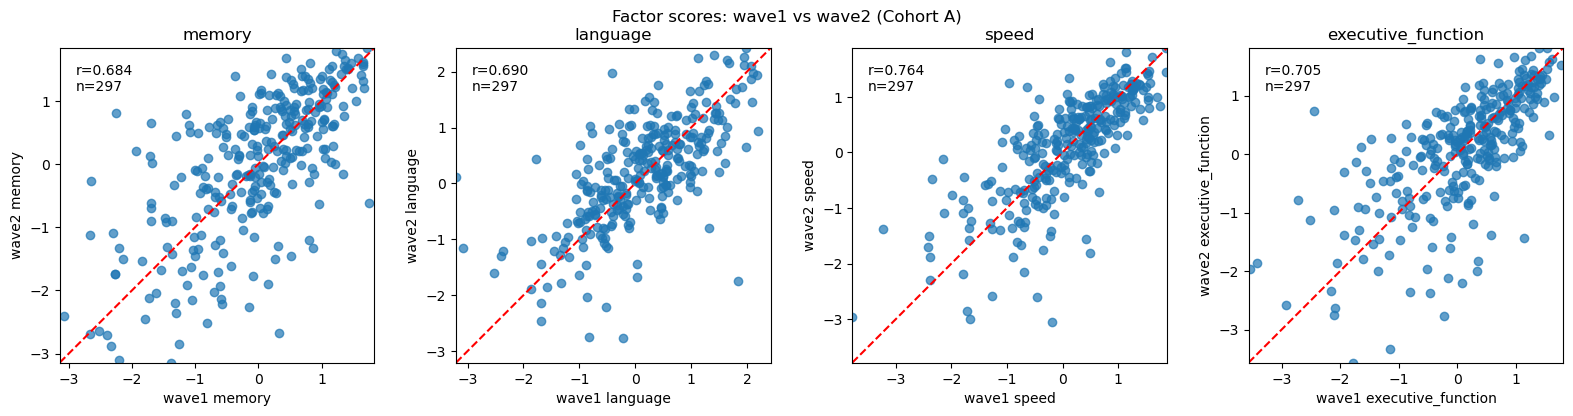


=== Cohort B: wave2 → wave3 ===


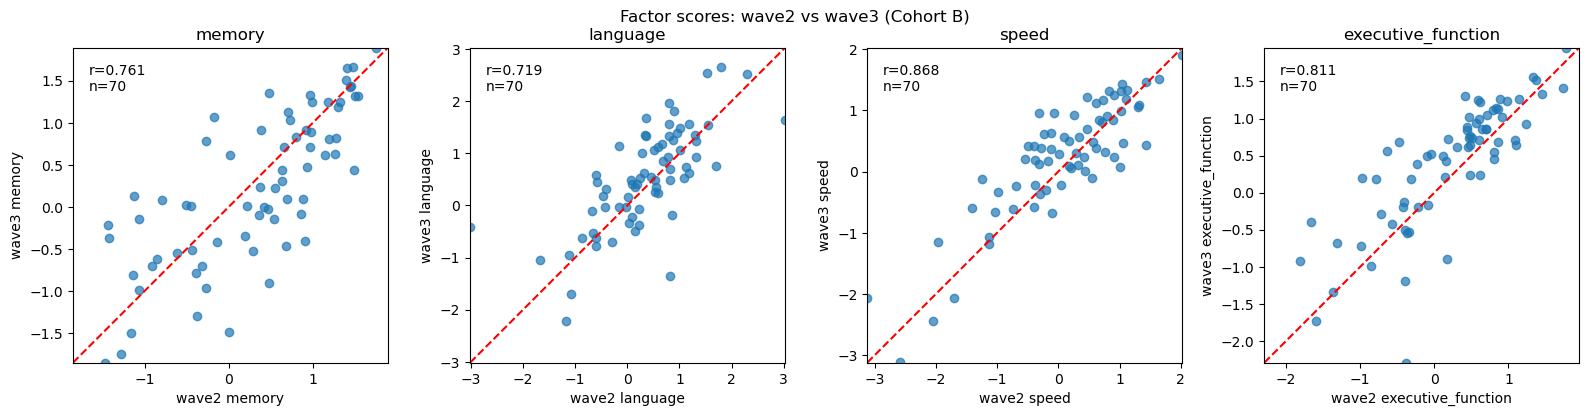

In [6]:
for label, wave_a, wave_b in cohorts:
    print(f'\n=== {label}: {wave_a} → {wave_b} ===')
    scatter_factors(comparisons[label], label, wave_a, wave_b, factor_cols)


=== Cohort A: wave1 → wave2 ===


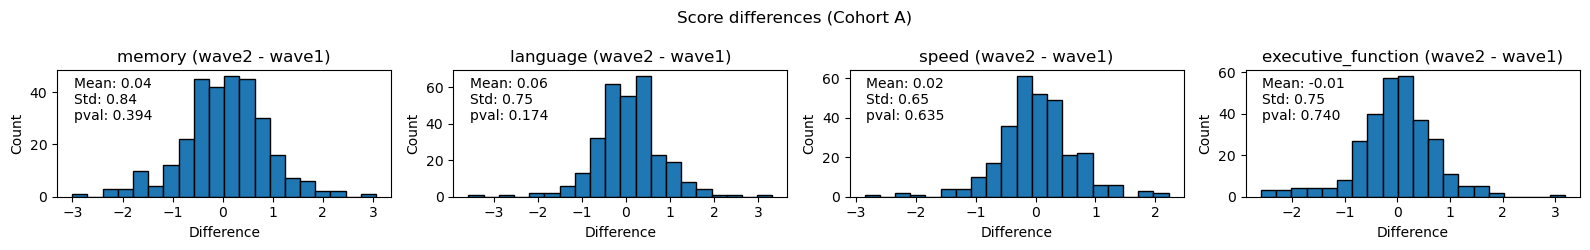


=== Cohort B: wave2 → wave3 ===


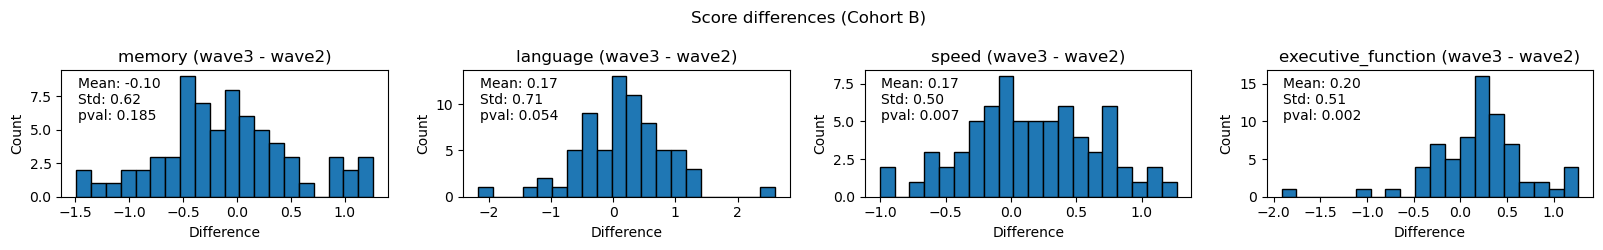

In [7]:
for label, wave_a, wave_b in cohorts:
    print(f'\n=== {label}: {wave_a} → {wave_b} ===')
    hist_differences(comparisons[label], label, wave_a, wave_b, factor_cols)

In [8]:
summaries = {}
for label, wave_a, wave_b in cohorts:
    summaries[label] = build_summary(comparisons[label], label, wave_a, wave_b, factor_cols)
    print(f'\n=== {label}: {wave_a} → {wave_b} ===')
    display(summaries[label])


=== Cohort A: wave1 → wave2 ===


,factor,wave1,wave2,\% Improvement / \% Decline,Difference,$p$-val
0,Memory,-0.01 $\pm$ 1.00,0.03 $\pm$ 1.11,53.2\% / 46.8\%,0.04 $\pm$ 0.84,0.39
1,Language,0.14 $\pm$ 0.96,0.20 $\pm$ 0.95,52.5\% / 47.5\%,0.06 $\pm$ 0.75,0.17
2,Speed,0.10 $\pm$ 0.94,0.11 $\pm$ 0.95,48.5\% / 51.5\%,0.02 $\pm$ 0.65,0.64
3,Executive Function,0.10 $\pm$ 0.97,0.09 $\pm$ 0.99,50.5\% / 49.5\%,-0.01 $\pm$ 0.75,0.74



=== Cohort B: wave2 → wave3 ===


,factor,wave2,wave3,\% Improvement / \% Decline,Difference,$p$-val
0,Memory,0.33 $\pm$ 0.89,0.23 $\pm$ 0.90,40.0\% / 60.0\%,-0.10 $\pm$ 0.62,0.18
1,Language,0.36 $\pm$ 0.93,0.53 $\pm$ 0.97,61.4\% / 38.6\%,0.17 $\pm$ 0.71,0.05
2,Speed,0.07 $\pm$ 1.00,0.24 $\pm$ 0.95,60.0\% / 40.0\%,0.17 $\pm$ 0.50,0.01
3,Executive Function,0.21 $\pm$ 0.81,0.40 $\pm$ 0.84,72.9\% / 27.1\%,0.20 $\pm$ 0.51,0.00


In [9]:
for label, wave_a, wave_b in cohorts:
    summary_df = summaries[label]
    cohort_slug = label.lower().replace(' ', '_')
    wave_nrs = [wave_a.replace("wave",""), wave_b.replace("wave","")]
    summary_latex = summary_df.to_latex(
        index=False,
        float_format="%.2f",
        column_format="lccccc",
        label=f"tab:cognitive_scores_{cohort_slug}",
        caption=(
            f"Summary of composite cognitive scores for {label}. We report mean and standard deviation of score in each wave and their difference."
        ),
        escape=False,
        multicolumn=True,
        multicolumn_format="c",
    )
    print(f'\n% === Cognitive scores {label}: {wave_a} → {wave_b}  ({now()}) ===')
    print(summary_latex)


% === Cognitive scores Cohort A: wave1 → wave2  (2026-07-17 13:27) ===
\begin{table}
\caption{Summary of composite cognitive scores for Cohort A. We report mean and standard deviation of score in each wave and their difference.}
\label{tab:cognitive_scores_cohort_a}
\begin{tabular}{lccccc}
\toprule
factor & wave1 & wave2 & \% Improvement / \% Decline & Difference & $p$-val \\
\midrule
Memory & -0.01 $\pm$ 1.00 & 0.03 $\pm$ 1.11 & 53.2\% / 46.8\% & 0.04 $\pm$ 0.84 & 0.39 \\
Language & 0.14 $\pm$ 0.96 & 0.20 $\pm$ 0.95 & 52.5\% / 47.5\% & 0.06 $\pm$ 0.75 & 0.17 \\
Speed & 0.10 $\pm$ 0.94 & 0.11 $\pm$ 0.95 & 48.5\% / 51.5\% & 0.02 $\pm$ 0.65 & 0.64 \\
Executive Function & 0.10 $\pm$ 0.97 & 0.09 $\pm$ 0.99 & 50.5\% / 49.5\% & -0.01 $\pm$ 0.75 & 0.74 \\
\bottomrule
\end{tabular}
\end{table}


% === Cognitive scores Cohort B: wave2 → wave3  (2026-07-17 13:27) ===
\begin{table}
\caption{Summary of composite cognitive scores for Cohort B. We report mean and standard deviation of score in each


=== Cohort A: wave1 → wave2 ===


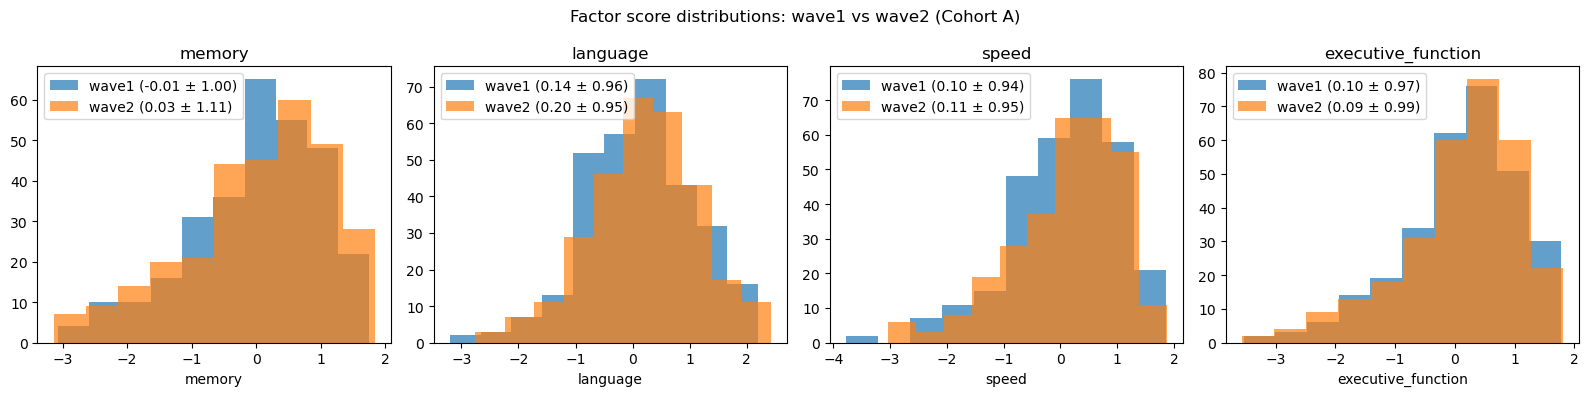


=== Cohort B: wave2 → wave3 ===


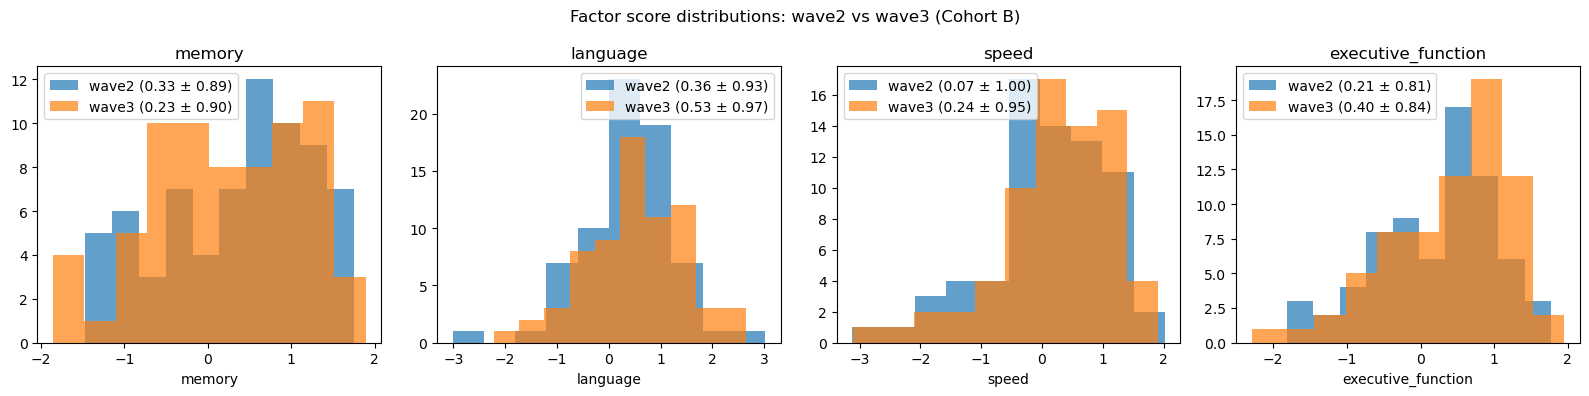

In [10]:
for label, wave_a, wave_b in cohorts:
    print(f'\n=== {label}: {wave_a} → {wave_b} ===')
    hist_marginals(comparisons[label], label, wave_a, wave_b, factor_cols)

### Potential practice effects within Cohort A

In [11]:
from util.helpers import prepare_demographics
from scipy.stats import ttest_ind

factor_scores = data.factor_scores_theory.copy()
targets = list(factor_scores.columns)
factor_scores['sample_name'] = data.sample_names
factor_scores['wave'] = data.waves
factor_scores['longitudinal_waves'] = data.longitudinal_waves
demographics_prepared, _ = prepare_demographics(data.demographics, include_socioeconomic=True)
demographic_columns = list(demographics_prepared.columns)
factor_scores = pd.concat((factor_scores, demographics_prepared), axis=1)
factor_scores

,composite_memory,composite_language,composite_speed,composite_executive_function,sample_name,wave,longitudinal_waves,age,gender_unified,education_binary,country,socioeconomic
0,NaN,NaN,NaN,NaN,41,wave1,[wave1],61.0,0,1.0,0.0,7.0
1,NaN,NaN,NaN,NaN,43,wave1,"[wave1, wave2]",63.0,0,1.0,0.0,7.0
2,NaN,NaN,NaN,NaN,44,wave1,"[wave1, wave2]",64.0,1,1.0,0.0,7.0
3,NaN,NaN,NaN,NaN,46,wave1,[wave1],62.0,1,0.0,0.0,2.0
4,NaN,NaN,NaN,NaN,49,wave1,[wave1],73.0,1,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1476,0.009962,1.059569,0.286316,0.523724,1946,wave3,"[wave2, wave3]",61.0,0,1.0,0.0,6.0
1477,0.433639,1.380432,0.389651,1.147031,1947,wave3,"[wave2, wave3]",62.0,0,0.0,0.0,2.0
1478,-0.545741,-0.021867,0.192694,0.232663,1949,wave3,"[wave2, wave3]",70.0,1,1.0,0.0,6.0
1479,-0.149979,0.536164,0.849361,0.768990,1950,wave3,"[wave2, wave3]",61.0,1,1.0,0.0,4.0


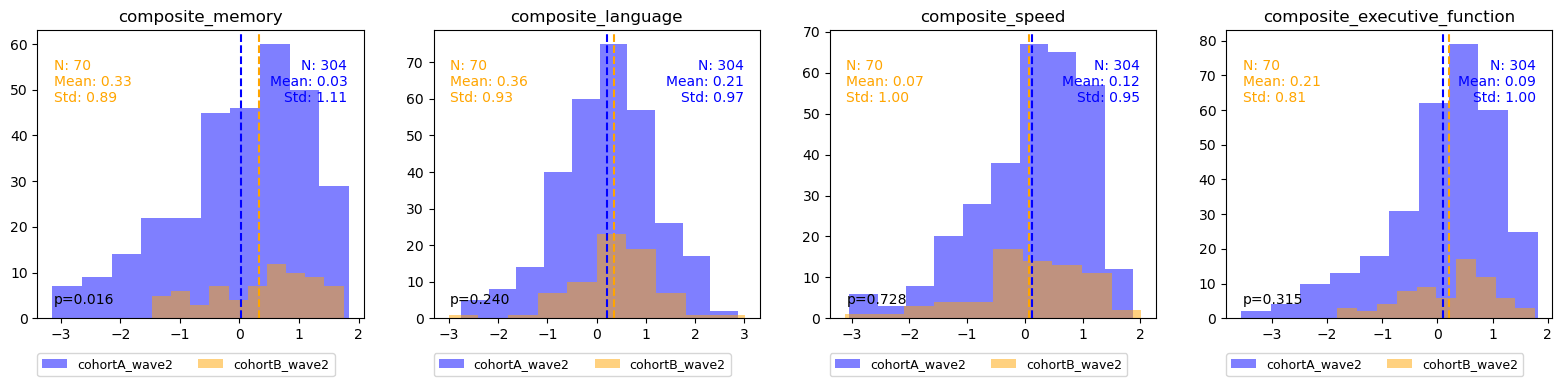

In [12]:

# plot histogram of each col in factor_scores (one subplot), and add mean and std in in each plot
fix, axes = plt.subplots(1, len(targets), figsize=(16, 4))
for i, col in enumerate(targets):
    cohortA_wave2 = factor_scores[factor_scores['longitudinal_waves'].apply(lambda waves: 'wave1' in waves and 'wave2' in waves) & (factor_scores['wave'] == 'wave2')].copy()
    cohortB_wave2 = factor_scores[factor_scores['longitudinal_waves'].apply(lambda waves: 'wave2' in waves and 'wave3' in waves) & (factor_scores['wave'] == 'wave2')].copy()
    subsets = {'cohortA_wave2': cohortA_wave2, 'cohortB_wave2': cohortB_wave2}
    for subset_label, subset in subsets.items():
        is_cohortA = subset_label == 'cohortA_wave2'
        subset[col].hist(ax=axes[i], alpha=0.5, label=subset_label, color='blue' if is_cohortA else 'orange')
        axes[i].axvline(subset[col].mean(), linestyle='--', c='blue' if is_cohortA else 'orange')
        axes[i].set_title(col)
        x = 0.95 if is_cohortA else 0.05
        ha = 'right' if is_cohortA else 'left'
        axes[i].text(x, 0.75, f'N: {subset[col].dropna().shape[0]}\nMean: {subset[col].mean():.2f}\nStd: {subset[col].std():.2f}', transform=axes[i].transAxes, fontsize=10, horizontalalignment=ha, color='blue' if is_cohortA else 'orange')
    pval = ttest_ind(subsets['cohortA_wave2'][col], subsets['cohortB_wave2'][col], equal_var=False, nan_policy='omit').pvalue
    axes[i].text(0.05, 0.05, f'p={pval:.3f}', transform=axes[i].transAxes, fontsize=10, horizontalalignment='left', color='k')
    axes[i].grid(False)
    axes[i].legend(ncol=2, loc=(0,-0.2), fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# this is not controlling for demographic variables though

In [14]:
# fit a proper stats model insteda

In [15]:
import statsmodels.formula.api as smf

cohortA_wave2 = factor_scores[factor_scores['longitudinal_waves'].apply(lambda waves: 'wave1' in waves and 'wave2' in waves) & (factor_scores['wave'] == 'wave2')].copy()
cohortB_wave2 = factor_scores[factor_scores['longitudinal_waves'].apply(lambda waves: 'wave2' in waves and 'wave3' in waves) & (factor_scores['wave'] == 'wave2')].copy()

results = {}
for col in targets:
    df = pd.concat([
        cohortA_wave2[[col] + demographic_columns].assign(group='A_followup'),
        cohortB_wave2[[col] + demographic_columns].assign(group='B_baseline'),
    ])
    model = smf.ols(
        f'{col} ~ C(group) + age + C(gender_unified) + C(education_binary) + C(country) + socioeconomic',
        data=df
    ).fit()
    results[col] = {
        'estimate': model.params['C(group)[T.B_baseline]'],
        'se': model.bse['C(group)[T.B_baseline]'],
        'ci': model.conf_int().loc['C(group)[T.B_baseline]'].tolist(),
        'pval': model.pvalues['C(group)[T.B_baseline]'],
    }
results

{'composite_memory': {'estimate': np.float64(0.061651226502328495),
  'se': np.float64(0.1422508759303143),
  'ci': [-0.21807785858281623, 0.34138031158747323],
  'pval': np.float64(0.6649803700733902)},
 'composite_language': {'estimate': np.float64(-0.09974826238344196),
  'se': np.float64(0.13109463992670403),
  'ci': [-0.3575391789344778, 0.15804265416759383],
  'pval': np.float64(0.4472129043738034)},
 'composite_speed': {'estimate': np.float64(-0.08198014852076356),
  'se': np.float64(0.13419009913807708),
  'ci': [-0.3458581275763561, 0.18189783053482894],
  'pval': np.float64(0.5416271034223122)},
 'composite_executive_function': {'estimate': np.float64(-0.0553247900389258),
  'se': np.float64(0.1327315050793864),
  'ci': [-0.31633451834470894, 0.20568493826685733],
  'pval': np.float64(0.6770557211061704)}}